# Week 4 Day 2

# Probability Distributions

## Objective

Analyze the distribution of Reliance daily returns.

Tasks:

1. Plot daily returns histogram.
2. Fit and overlay a normal distribution.
3. Create a Q-Q plot.
4. Determine whether returns appear normally distributed.

In [9]:
import pandas as pd
import numpy as np

import yfinance as yf

import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.stats import probplot

In [10]:
reliance = yf.download(
    "RELIANCE.NS",
    period="5y",
    auto_adjust=True
)

reliance.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-06-16,1001.673279,1017.729219,999.068999,1016.755482,10797349
2021-06-17,1003.507507,1012.271500,987.315715,996.419342,15745975
2021-06-18,1008.036743,1012.271565,989.331240,1007.968816,29369026
2021-06-21,1013.290527,1017.932910,996.487334,998.004605,12186448
2021-06-22,1008.082031,1024.047462,1005.183342,1020.876946,12871913


In [11]:
if isinstance(reliance.columns, pd.MultiIndex):
    reliance.columns = reliance.columns.get_level_values(0)

In [12]:
reliance["Daily_Return"] = (
    reliance["Close"]
    .pct_change()
)

returns = (
    reliance["Daily_Return"]
    .dropna()
)

## Histogram of Daily Returns

The histogram shows the distribution of daily percentage returns.

A normal curve is overlaid for comparison.

In [13]:
mu = returns.mean()

sigma = returns.std()

print("Mean:", mu)

print("Std Dev:", sigma)

Mean: 0.00032229653081425444
Std Dev: 0.014063849368800617


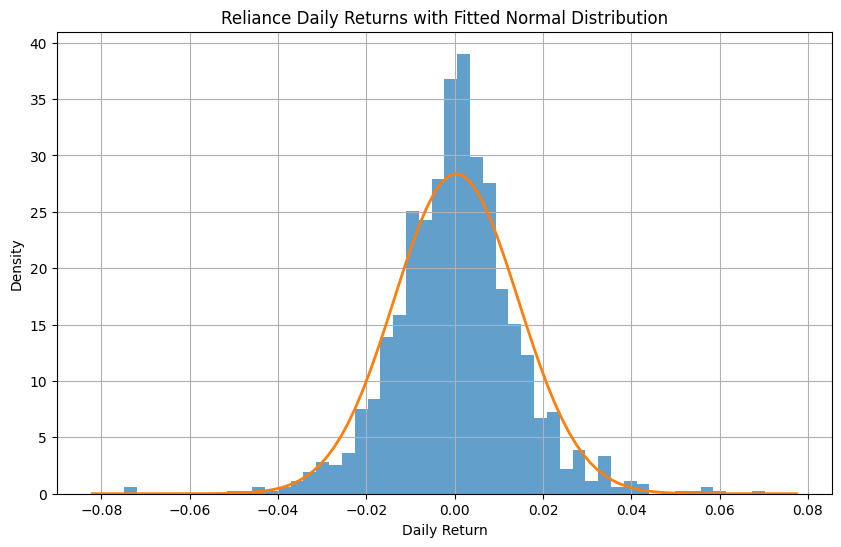

In [14]:
plt.figure(figsize=(10,6))

plt.hist(
    returns,
    bins=50,
    density=True,
    alpha=0.7
)

xmin, xmax = plt.xlim()

x = np.linspace(
    xmin,
    xmax,
    100
)

p = norm.pdf(
    x,
    mu,
    sigma
)

plt.plot(
    x,
    p,
    linewidth=2
)

plt.title(
    "Reliance Daily Returns with Fitted Normal Distribution"
)

plt.xlabel("Daily Return")

plt.ylabel("Density")

plt.grid(True)

plt.savefig(
    "../images/returns_histogram.png",
    dpi=150
)

plt.show()

## Q-Q Plot

The Q-Q plot compares the distribution of actual returns with a theoretical normal distribution.

If points follow a straight line, returns are approximately normal.

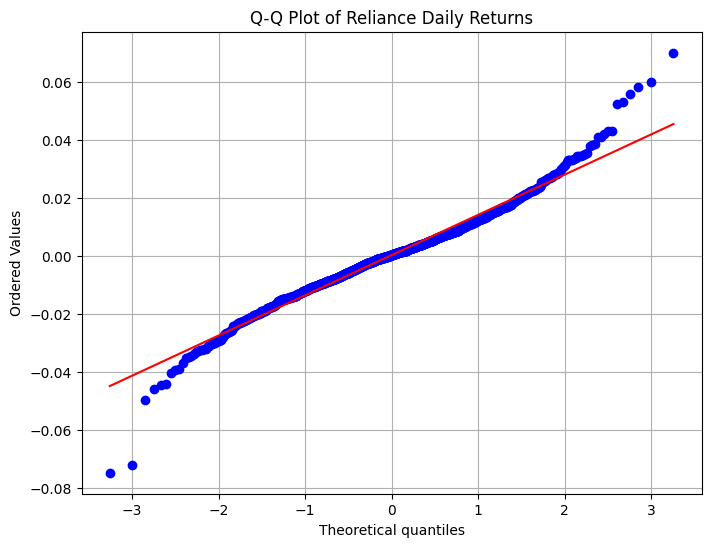

In [15]:
plt.figure(figsize=(8,6))

probplot(
    returns,
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot of Reliance Daily Returns"
)

plt.grid(True)

plt.savefig(
    "../images/qq_plot.png",
    dpi=150
)

plt.show()

# Interpretation

The histogram of Reliance daily returns is approximately bell-shaped, but it does not perfectly match a normal distribution.

The Q-Q plot shows that many points follow the reference line in the center, indicating that average returns behave similarly to a normal distribution.

However, points deviate from the line in the tails. This suggests the presence of extreme positive and negative returns that occur more frequently than predicted by a normal distribution.

Therefore, Reliance daily returns are approximately normal in the center but exhibit heavier tails, which is a common characteristic of financial return data.